#**IMPLEMENTACIÓN DEL MODELO**

Una vez terminada la depuración de los datos y el análisis exploratorio se procede a seleccionar el modelo a utilizar y su implementación, la que consiste en entrenar, validar y testear.

#**RANDOM FOREST**

En este cuaderno se entrena un modelo de clasificación (Random Forest) y se obtiene uno para predecir la probabilidad de riesgo de un evento de tránsito accidental, a partir de variables como clima, tipo de camino, momento del día, etc.

## **OBJETIVO DE LA IMPLEMENTACIÓN**

Generar un modelo predictivo que dé como resultado una probabilidad de riesgo a partir de variables ingresadas en una plataforma intuitiva y visual para la toma de decisiones de un usuario capacitado. La probabilidad de riesgo será asociada a un "nivel" de riesgo al conducir con determinadas condiciones.


## **Justificación de la elección del modelo**


*   El algoritmo random forest es capaz de establecer relaciones complejas (no lineales). El modelo establece las relaciones entre las variables sin necesidad de estar relacionándolas directamente.
*   Es un modelo que funciona bien con datos heterogéneos: categóricos y numéricos, como con los que contamos en el dataset.
*   Se reduce el riesgo de overfitting.
*   Permite generar métricas claras que favorecen la interpretabilidad de los resultados para entender mejor el fenómeno (importancia de cada variable)

#**Descripción de los datos**



---

.

#**IMPLEMENTACIÓN**

In [ ]:
## Se importan las librerías
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [ ]:
## Se carga el dataset de entrenamiento (CURADO 2)
# 1. Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Cargar el CSV desde la carpeta Curados
ruta = "/content/drive/MyDrive/IA- Sistema predictivo de accidentes en rutas/ML00- Datasets/Curados/dataset_entrenamiento_curado.csv"

df = pd.read_csv(ruta)

df.head()

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
0,despejado,camino urbano,tarde,2.0,30.0,2.0,1,media,seco,auto,22.0,3.0,luz diurna,1
1,despejado,autopista,atardecer,0.0,100.0,3.0,0,baja,seco,moto,41.0,7.0,luz diurna,0
2,lluvioso,camino urbano,tarde,2.0,40.0,1.0,0,baja,mojado,auto,80.0,24.0,luz diurna,0
3,despejado,autopista,noche,1.0,110.0,2.0,0,baja,seco,bus,32.0,6.0,luz artificial,0
4,despejado,camino urbano,noche,1.0,50.0,2.0,0,baja,seco,auto,42.0,18.0,luz artificial,0


In [ ]:
print(df)

In [ ]:
print(df.columns)


Index(['Clima', 'Tipo_de_Camino', 'Momento_del_Día', 'Densidad_de_Tráfico',
       'Límite_de_Velocidad', 'Número_de_Vehículos', 'Alcohol_en_Conductor',
       'Severidad_del_Accidente', 'Condición_del_Camino', 'Tipo_de_Vehículo',
       'Edad_del_Conductor', 'Experiencia_del_Conductor',
       'Condición_de_Iluminación_Vial', 'Accidente'],
      dtype='object')


## **Identificación variable objetivo**

**Se separan las variables atributo de la variable objetivo**

In [ ]:
y = df['Accidente']
X = df.drop(columns=['Accidente'])

In [ ]:
print(X.columns)

Index(['Clima', 'Tipo_de_Camino', 'Momento_del_Día', 'Densidad_de_Tráfico',
       'Límite_de_Velocidad', 'Número_de_Vehículos', 'Alcohol_en_Conductor',
       'Severidad_del_Accidente', 'Condición_del_Camino', 'Tipo_de_Vehículo',
       'Edad_del_Conductor', 'Experiencia_del_Conductor',
       'Condición_de_Iluminación_Vial'],
      dtype='object')


In [ ]:
print(y)

0       1
1       0
2       0
3       0
4       0
       ..
1581    1
1582    1
1583    0
1584    0
1585    0
Name: Accidente, Length: 1586, dtype: int64


# **ANÁLISIS EXPLORATORIO EDA**

## **Columnas categóricas**


In [ ]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns

X_cat = X[cat_cols]

print("Columnas categóricas:")
print(cat_cols)

Columnas categóricas:
Index(['Clima', 'Tipo_de_Camino', 'Momento_del_Día', 'Severidad_del_Accidente',
       'Condición_del_Camino', 'Tipo_de_Vehículo',
       'Condición_de_Iluminación_Vial'],
      dtype='object')


## **Aislamiento de atributos**

**Se identifican y separan los atributos derivados de accidentes**

El objetivo es evitar que generen sesgos o peso en el modelo.

Es el caso de:

Número_de_Vehículos

Severidad_del_Accidente

Edad_del_Conductor

Experiencia_del_Conductor

Alcohol_en_Conductor


In [ ]:
X = X.drop(columns=['Severidad_del_Accidente', 'Número_de_Vehículos', 'Edad_del_Conductor', 'Experiencia_del_Conductor', 'Alcohol_en_Conductor'], errors='ignore')

**Se conservan la siguientes variables:**

'Clima', 'Tipo_de_Camino', 'Momento_del_Día', 'Densidad_de_Tráfico',
       'Límite_de_Velocidad', 'Condición_del_Camino', 'Tipo_de_Vehículo',
       'Condición_de_Iluminación_Vial'

In [ ]:
print(X.columns)

Index(['Clima', 'Tipo_de_Camino', 'Momento_del_Día', 'Densidad_de_Tráfico',
       'Límite_de_Velocidad', 'Condición_del_Camino', 'Tipo_de_Vehículo',
       'Condición_de_Iluminación_Vial'],
      dtype='object')


In [ ]:
print(y)

0       1
1       0
2       0
3       0
4       0
       ..
1581    1
1582    1
1583    0
1584    0
1585    0
Name: Accidente, Length: 1586, dtype: int64


## **Revisión del balance de la variable objetivo**

In [ ]:
y.value_counts()
y.value_counts(normalize=True)

,proportion
Accidente,
1,0.594578
0,0.405422


Se considera que estan bien representados los casos posibles dentro de la variable objetivo.

## **Revisión de valores faltantes**

In [ ]:
X.isnull().sum()

,0
Clima,0
Tipo_de_Camino,0
Momento_del_Día,0
Densidad_de_Tráfico,0
Límite_de_Velocidad,0
Condición_del_Camino,0
Tipo_de_Vehículo,0
Condición_de_Iluminación_Vial,0


No hay valores faltantes

## **Exploración de las variables numéricas**

In [ ]:
X.describe()


,Densidad_de_Tráfico,Límite_de_Velocidad
count,1586.000000,1586.000000
mean,1.171501,62.017654
std,0.796424,25.292528
min,0.000000,30.000000
25%,1.000000,40.000000
50%,1.000000,60.000000
75%,2.000000,80.000000
max,2.000000,120.000000


## **Cantidad de datos por categoría**

In [ ]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print("\nFrecuencias para:", col)
    print(X[col].value_counts())




Frecuencias para: Clima
Clima
despejado     948
lluvioso      236
neblinoso     154
nevado        131
tormentoso    117
Name: count, dtype: int64

Frecuencias para: Tipo_de_Camino
Tipo_de_Camino
camino urbano    872
autopista        365
camino rural     349
Name: count, dtype: int64

Frecuencias para: Momento_del_Día
Momento_del_Día
mañana       490
tarde        479
noche        324
atardecer    293
Name: count, dtype: int64

Frecuencias para: Condición_del_Camino
Condición_del_Camino
seco         1037
mojado        452
congelado      97
Name: count, dtype: int64

Frecuencias para: Tipo_de_Vehículo
Tipo_de_Vehículo
auto         969
camion       166
moto         156
bus          151
camioneta    144
Name: count, dtype: int64

Frecuencias para: Condición_de_Iluminación_Vial
Condición_de_Iluminación_Vial
luz diurna        999
luz artificial    471
sin luz           116
Name: count, dtype: int64


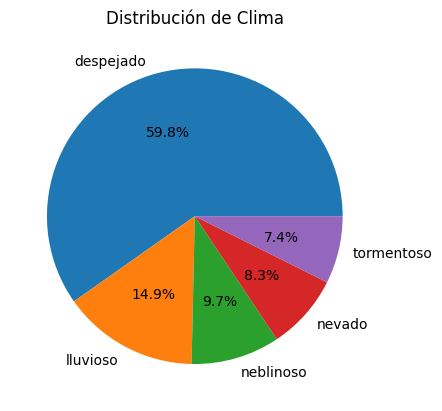

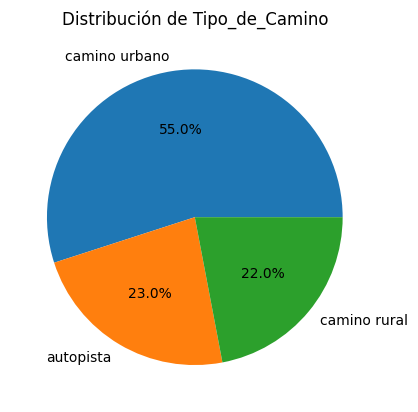

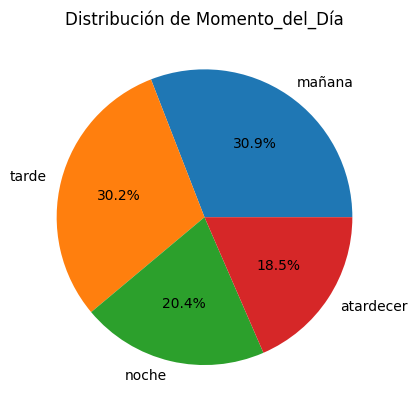

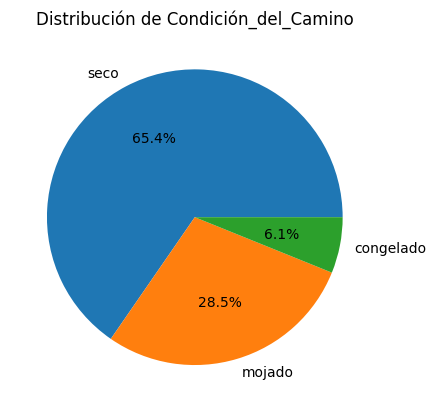

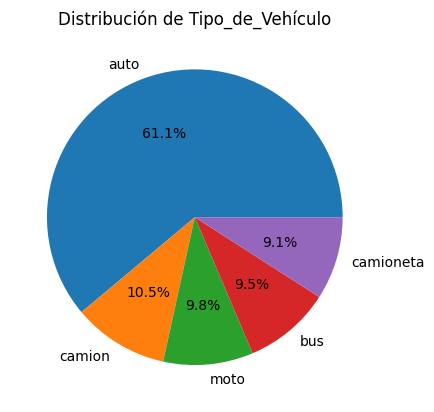

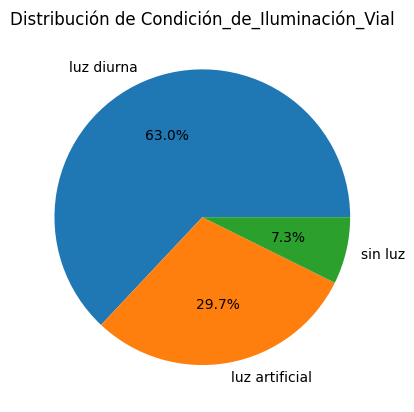

In [ ]:
import matplotlib.pyplot as plt

cat_cols = X.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    plt.figure()
    X[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'Distribución de {col}')
    plt.ylabel('')
    plt.show()

En el dataset predominan condiciones que consideramos normales de circulación, representan el escenario más frecuente a diferencia de los que favorecen a la probabilidad que ocurra un evento riesgoso como clima despejado, caminos urbanos, superficies secas, luz diurna y vehículos particulares.
La distribución de los datos relacionados a la variable "momento del día" es equilibrada, lo cual permite incluir las variaciones temporales.


## **Revisión de plausibilidad de variables (EDA conceptual)**

Los resultados son plausibles, se considera que hay diversidad y representatividad.

## **Relación preliminar con el accidente**

In [ ]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print("\nCrosstab para:", col)
    print(pd.crosstab(X[col], y))


Crosstab para: Clima
Accidente     0    1
Clima               
despejado   400  548
lluvioso     93  143
neblinoso    71   83
nevado       37   94
tormentoso   42   75

Crosstab para: Tipo_de_Camino
Accidente         0    1
Tipo_de_Camino          
autopista       152  213
camino rural    130  219
camino urbano   361  511

Crosstab para: Momento_del_Día
Accidente          0    1
Momento_del_Día          
atardecer        125  168
mañana           210  280
noche             92  232
tarde            216  263

Crosstab para: Condición_del_Camino
Accidente               0    1
Condición_del_Camino          
congelado              27   70
mojado                180  272
seco                  436  601

Crosstab para: Tipo_de_Vehículo
Accidente           0    1
Tipo_de_Vehículo          
auto              383  586
bus                73   78
camion             66  100
camioneta          54   90
moto               67   89

Crosstab para: Condición_de_Iluminación_Vial
Accidente                  

<Figure size 640x480 with 0 Axes>

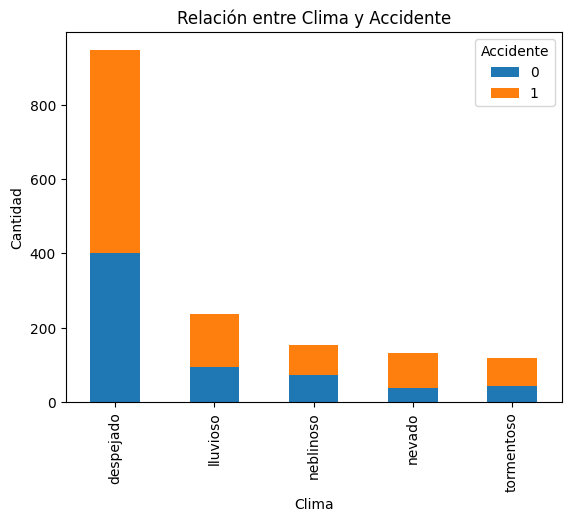

<Figure size 640x480 with 0 Axes>

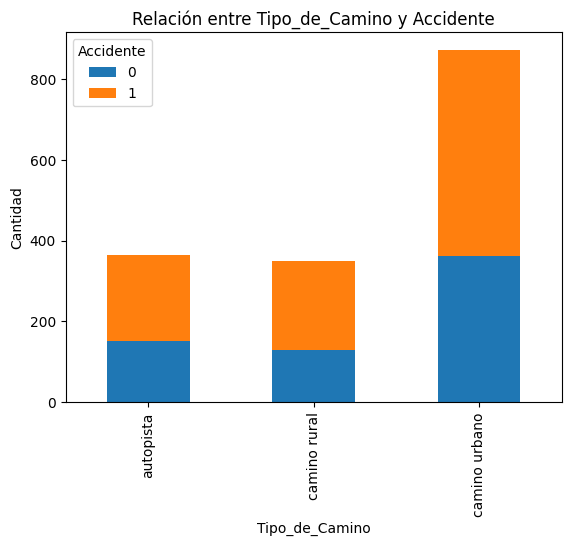

<Figure size 640x480 with 0 Axes>

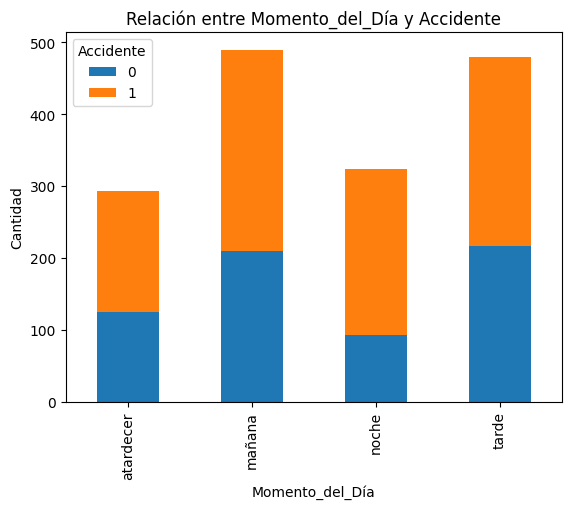

<Figure size 640x480 with 0 Axes>

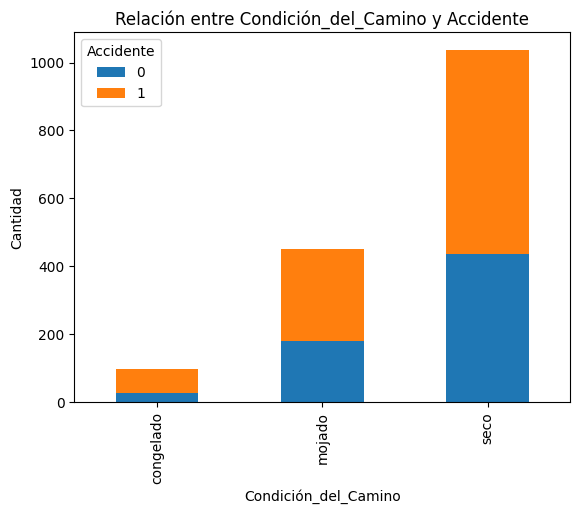

<Figure size 640x480 with 0 Axes>

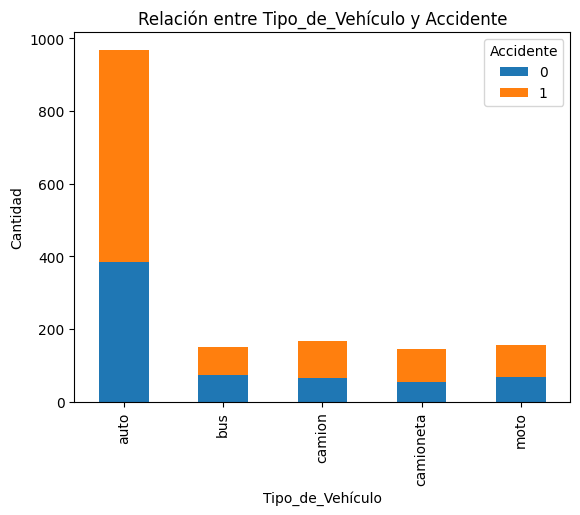

<Figure size 640x480 with 0 Axes>

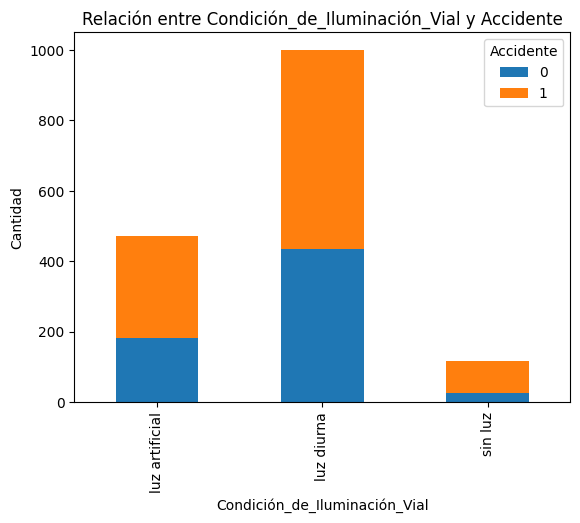

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

cat_cols = X.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    plt.figure()
    ct = pd.crosstab(X[col], y)
    ct.plot(kind='bar', stacked=True)
    plt.title(f'Relación entre {col} y Accidente')
    plt.xlabel(col)
    plt.ylabel('Cantidad')
    plt.legend(title='Accidente')
    plt.show()

**Se pueden identificar proporciones mayores de casos positivos cuando están presenten la siguientes condiciones:**


*   En climas: nevados, lluviosos o tormentosos.
*   En iluminación: luz artificial o sin luz
*   En condición del camino: congelado
*   En momento el día: noche






Control validación del dataset

In [ ]:
print("✅ Dataset recargado correctamente")
print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())

✅ Dataset recargado correctamente
Shape: (1586, 14)
Columnas: ['Clima', 'Tipo_de_Camino', 'Momento_del_Día', 'Densidad_de_Tráfico', 'Límite_de_Velocidad', 'Número_de_Vehículos', 'Alcohol_en_Conductor', 'Severidad_del_Accidente', 'Condición_del_Camino', 'Tipo_de_Vehículo', 'Edad_del_Conductor', 'Experiencia_del_Conductor', 'Condición_de_Iluminación_Vial', 'Accidente']


In [ ]:
print("✅ Dataset recargado correctamente")
print("Shape:", X.shape)
print("Columnas:", X.columns.tolist())

✅ Dataset recargado correctamente
Shape: (1586, 8)
Columnas: ['Clima', 'Tipo_de_Camino', 'Momento_del_Día', 'Densidad_de_Tráfico', 'Límite_de_Velocidad', 'Condición_del_Camino', 'Tipo_de_Vehículo', 'Condición_de_Iluminación_Vial']


# **VARIABLES DERIVADAS**

Se crean variables a partir de los atributos conocidos.

Se crean cuatro atributos derivados los originales.
Se identifican escenarios con probabilidad de riesgo :

*   **Riesgo_Noche_Sin_Luz:** Combinación noche + sin luz
*   **Riesgo clima peligroso:** lluvioso, neblinoso, nevado, tormentoso
*   **Riesgo camino resbaladizo:** mojado, congelado
*   **Riesgo factor velocidad:** límites de velocidad mayores a 80km/h

In [ ]:
X["Riesgo_Noche_Sin_Luz"] = ((X["Momento_del_Día"] == "noche") & (X["Condición_de_Iluminación_Vial"] == "sin luz")).astype(int)

X["Clima_Peligroso"] = X["Clima"].isin(["lluvioso", "neblinoso", "nevado", "tormentoso"]).astype(int)

X["Condicion_Resbaladiza"] = X["Condición_del_Camino"].isin(["mojado", "congelado"]).astype(int)

X["Velocidad_Alta"] = (X["Límite_de_Velocidad"] >= 80).astype(int)

In [ ]:
print(X.columns)

Index(['Clima', 'Tipo_de_Camino', 'Momento_del_Día', 'Densidad_de_Tráfico',
       'Límite_de_Velocidad', 'Condición_del_Camino', 'Tipo_de_Vehículo',
       'Condición_de_Iluminación_Vial', 'Riesgo_Noche_Sin_Luz',
       'Clima_Peligroso', 'Condicion_Resbaladiza', 'Velocidad_Alta'],
      dtype='object')


# **PREPARACION DE DATOS PARA MODELADO**

## **Encoding**

**Se aplica el encoding para transformar los datos categóricos en valores numéricos que el modelo pueda entender.**

Ya que el modelo no detecta texto es necesario transformar los textos en números.

Para este proyecto se aplica **One-Hot Encoding** ya que evita que se generen jerarquias artificiales entre las variables categóricas.

##***La codificación transforma las variables categóricas en representaciones binarias.***

No se imponen supuestos de continuidad o monotonicidad ya que el modelo identifica ausencia (0) o presencia (1) de la variable.

In [ ]:
cat_X= X.select_dtypes(include=['object', 'category'])

print("Columnas categóricas:")
print(cat_X)

Columnas categóricas:
          Clima Tipo_de_Camino Momento_del_Día Condición_del_Camino  \
0     despejado  camino urbano           tarde                 seco   
1     despejado      autopista       atardecer                 seco   
2      lluvioso  camino urbano           tarde               mojado   
3     despejado      autopista           noche                 seco   
4     despejado  camino urbano           noche                 seco   
...         ...            ...             ...                  ...   
1581  despejado      autopista           tarde                 seco   
1582  neblinoso  camino urbano           tarde               mojado   
1583  despejado   camino rural           tarde                 seco   
1584     nevado  camino urbano       atardecer                 seco   
1585  despejado  camino urbano           tarde                 seco   

     Tipo_de_Vehículo Condición_de_Iluminación_Vial  
0                auto                    luz diurna  
1                

In [ ]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

cat_X = encoder.fit_transform(cat_X)

In [ ]:
print("Columnas numéricas:")
print(cat_X)

Columnas numéricas:
[[1. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 1. 0.]
 ...
 [1. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 1. 0.]]




---



---



In [ ]:
cat2_X= X.select_dtypes(include=['object', 'category'])

print("Columnas categóricas:")
print(cat2_X)

Columnas categóricas:
          Clima Tipo_de_Camino Momento_del_Día Condición_del_Camino  \
0     despejado  camino urbano           tarde                 seco   
1     despejado      autopista       atardecer                 seco   
2      lluvioso  camino urbano           tarde               mojado   
3     despejado      autopista           noche                 seco   
4     despejado  camino urbano           noche                 seco   
...         ...            ...             ...                  ...   
1581  despejado      autopista           tarde                 seco   
1582  neblinoso  camino urbano           tarde               mojado   
1583  despejado   camino rural           tarde                 seco   
1584     nevado  camino urbano       atardecer                 seco   
1585  despejado  camino urbano           tarde                 seco   

     Tipo_de_Vehículo Condición_de_Iluminación_Vial  
0                auto                    luz diurna  
1                

In [ ]:
print("Columnas categóricas:")
print(cat2_X.columns)

Columnas categóricas:
Index(['Clima', 'Tipo_de_Camino', 'Momento_del_Día', 'Condición_del_Camino',
       'Tipo_de_Vehículo', 'Condición_de_Iluminación_Vial'],
      dtype='object')


In [ ]:
X= X.drop(columns=['Clima', 'Tipo_de_Camino', 'Momento_del_Día', 'Condición_del_Camino',
       'Tipo_de_Vehículo', 'Condición_de_Iluminación_Vial'])

In [ ]:
print(X.columns)

Index(['Densidad_de_Tráfico', 'Límite_de_Velocidad', 'Riesgo_Noche_Sin_Luz',
       'Clima_Peligroso', 'Condicion_Resbaladiza', 'Velocidad_Alta'],
      dtype='object')


In [ ]:
print(X)

      Densidad_de_Tráfico  Límite_de_Velocidad  Riesgo_Noche_Sin_Luz  \
0                     2.0                 30.0                     0   
1                     0.0                100.0                     0   
2                     2.0                 40.0                     0   
3                     1.0                110.0                     0   
4                     1.0                 50.0                     0   
...                   ...                  ...                   ...   
1581                  2.0                110.0                     0   
1582                  2.0                 60.0                     0   
1583                  0.0                 70.0                     0   
1584                  0.0                 50.0                     0   
1585                  1.0                 60.0                     0   

      Clima_Peligroso  Condicion_Resbaladiza  Velocidad_Alta  
0                   0                      0               0  
1        

In [ ]:
feature_names = encoder.get_feature_names_out()
cat_X_fn = pd.DataFrame(cat_X, columns=feature_names, index=cat2_X.index)

In [ ]:
print(X)

      Densidad_de_Tráfico  Límite_de_Velocidad  Riesgo_Noche_Sin_Luz  \
0                     2.0                 30.0                     0   
1                     0.0                100.0                     0   
2                     2.0                 40.0                     0   
3                     1.0                110.0                     0   
4                     1.0                 50.0                     0   
...                   ...                  ...                   ...   
1581                  2.0                110.0                     0   
1582                  2.0                 60.0                     0   
1583                  0.0                 70.0                     0   
1584                  0.0                 50.0                     0   
1585                  1.0                 60.0                     0   

      Clima_Peligroso  Condicion_Resbaladiza  Velocidad_Alta  
0                   0                      0               0  
1        

In [ ]:
print(cat_X_fn)

      Clima_despejado  Clima_lluvioso  Clima_neblinoso  Clima_nevado  \
0                 1.0             0.0              0.0           0.0   
1                 1.0             0.0              0.0           0.0   
2                 0.0             1.0              0.0           0.0   
3                 1.0             0.0              0.0           0.0   
4                 1.0             0.0              0.0           0.0   
...               ...             ...              ...           ...   
1581              1.0             0.0              0.0           0.0   
1582              0.0             0.0              1.0           0.0   
1583              1.0             0.0              0.0           0.0   
1584              0.0             0.0              0.0           1.0   
1585              1.0             0.0              0.0           0.0   

      Clima_tormentoso  Tipo_de_Camino_autopista  Tipo_de_Camino_camino rural  \
0                  0.0                       0.0      

In [ ]:

# 3. Concatenar el DataFrame X (que ahora solo tiene variables numéricas originales)
# con el nuevo DataFrame de variables categóricas transformadas
X = pd.concat([X, cat_X_fn], axis=1)

# Verificar el resultado
print(X.head())

   Densidad_de_Tráfico  Límite_de_Velocidad  Riesgo_Noche_Sin_Luz  \
0                  2.0                 30.0                     0   
1                  0.0                100.0                     0   
2                  2.0                 40.0                     0   
3                  1.0                110.0                     0   
4                  1.0                 50.0                     0   

   Clima_Peligroso  Condicion_Resbaladiza  Velocidad_Alta  Clima_despejado  \
0                0                      0               0              1.0   
1                0                      0               1              1.0   
2                1                      1               0              0.0   
3                0                      0               1              1.0   
4                0                      0               0              1.0   

   Clima_lluvioso  Clima_neblinoso  Clima_nevado  ...  \
0             0.0              0.0           0.0  ...   
1 

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identificamos las columnas numéricas que no son binarias (dummies)
# Según tu dataset: Densidad_de_Tráfico y Limite_de_Velocidad
cols_a_escalar = ['Densidad_de_Tráfico', 'Límite_de_Velocidad']

scaler = StandardScaler()

# Ajustamos y transformamos solo esas columnas en el set de entrenamiento
X[cols_a_escalar] = scaler.fit_transform(X[cols_a_escalar])

print("Datos escalados correctamente. Primeras filas:")
print(X[cols_a_escalar].head())

Datos escalados correctamente. Primeras filas:
   Densidad_de_Tráfico  Límite_de_Velocidad
0             1.040602            -1.266293
1            -1.471415             1.502196
2             1.040602            -0.870795
3            -0.215406             1.897694
4            -0.215406            -0.475296


In [ ]:
print(X.head())

   Densidad_de_Tráfico  Límite_de_Velocidad  Riesgo_Noche_Sin_Luz  \
0             1.040602            -1.266293                     0   
1            -1.471415             1.502196                     0   
2             1.040602            -0.870795                     0   
3            -0.215406             1.897694                     0   
4            -0.215406            -0.475296                     0   

   Clima_Peligroso  Condicion_Resbaladiza  Velocidad_Alta  Clima_despejado  \
0                0                      0               0              1.0   
1                0                      0               1              1.0   
2                1                      1               0              0.0   
3                0                      0               1              1.0   
4                0                      0               0              1.0   

   Clima_lluvioso  Clima_neblinoso  Clima_nevado  ...  \
0             0.0              0.0           0.0  ...   
1 

In [ ]:
print(X.columns)

Index(['Densidad_de_Tráfico', 'Límite_de_Velocidad', 'Riesgo_Noche_Sin_Luz',
       'Clima_Peligroso', 'Condicion_Resbaladiza', 'Velocidad_Alta',
       'Clima_despejado', 'Clima_lluvioso', 'Clima_neblinoso', 'Clima_nevado',
       'Clima_tormentoso', 'Tipo_de_Camino_autopista',
       'Tipo_de_Camino_camino rural', 'Tipo_de_Camino_camino urbano',
       'Momento_del_Día_atardecer', 'Momento_del_Día_mañana',
       'Momento_del_Día_noche', 'Momento_del_Día_tarde',
       'Condición_del_Camino_congelado', 'Condición_del_Camino_mojado',
       'Condición_del_Camino_seco', 'Tipo_de_Vehículo_auto',
       'Tipo_de_Vehículo_bus', 'Tipo_de_Vehículo_camion',
       'Tipo_de_Vehículo_camioneta', 'Tipo_de_Vehículo_moto',
       'Condición_de_Iluminación_Vial_luz artificial',
       'Condición_de_Iluminación_Vial_luz diurna',
       'Condición_de_Iluminación_Vial_sin luz'],
      dtype='object')


###**ENTRENAMIENTO**

--- MÉTRICAS FINALES (Umbral Ajustado: 0.4) ---
ROC-AUC Score: 0.6736
              precision    recall  f1-score   support

           0       0.84      0.05      0.09       643
           1       0.61      0.99      0.75       943

    accuracy                           0.61      1586
   macro avg       0.72      0.52      0.42      1586
weighted avg       0.70      0.61      0.49      1586



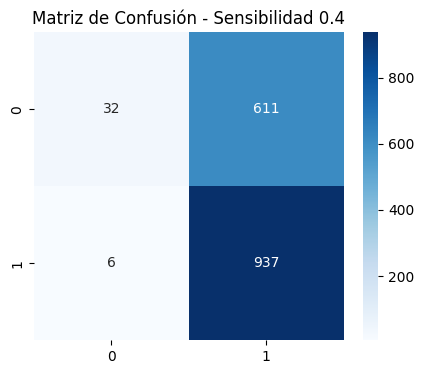

✅ Exportado sin ZipMap en: /content/modelo_riesgo_vial_nozipmap.onnx
¿Existe el archivo?: True
Tamaño (bytes): 204845
Archivos en /content: ['.config', 'modelo_riesgo_vial.onnx', 'drive', 'modelo_riesgo_vial_nozipmap.onnx', 'sample_data']


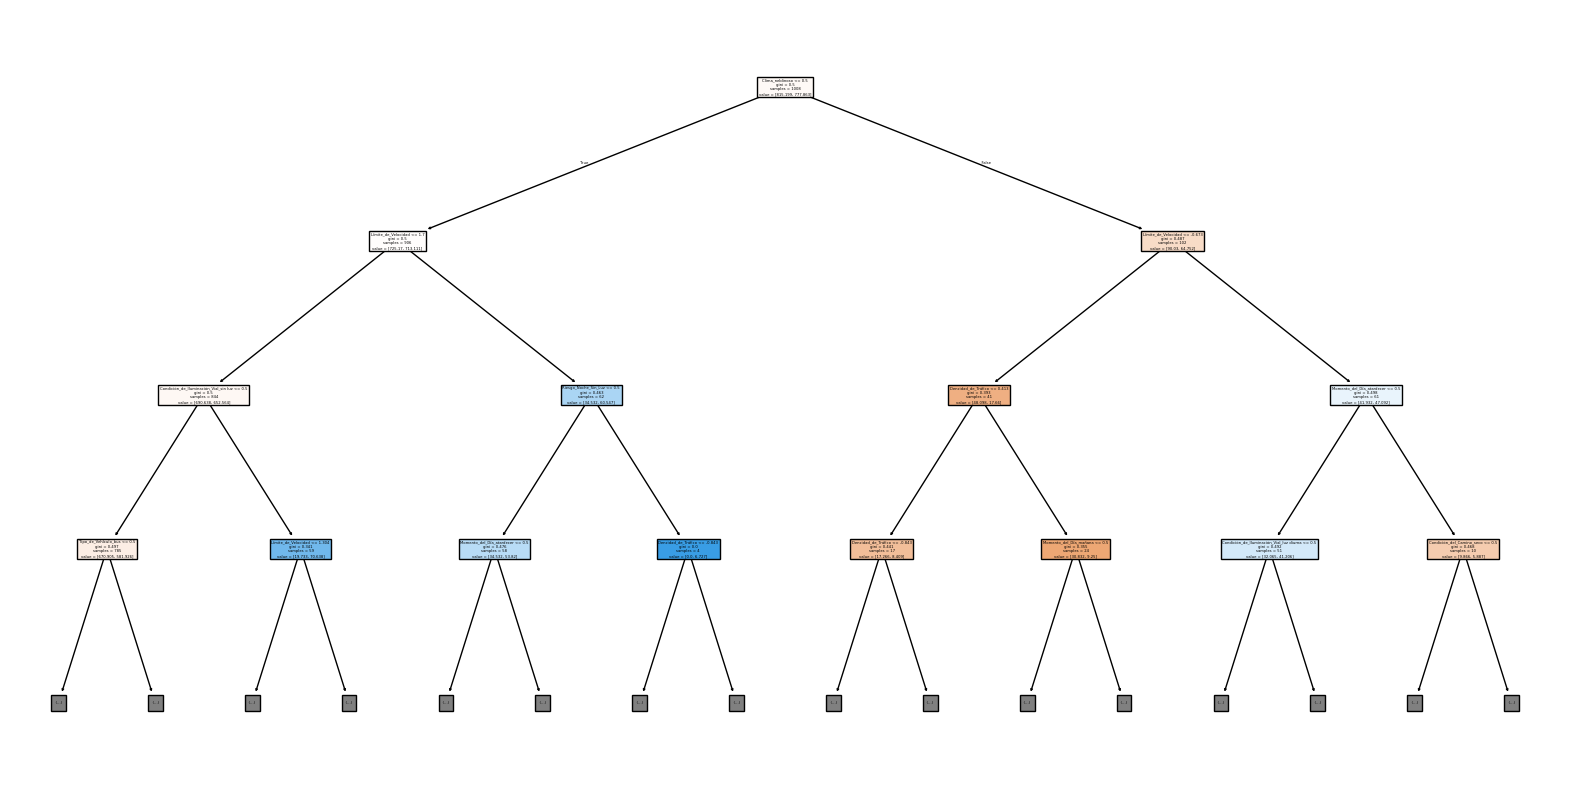

In [ ]:
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

# 1. BÚSQUEDA DE MEJORES PARÁMETROS (Grid Search)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'class_weight': ['balanced'] # Mantenemos el balance para compensar el 60/40 [cite: 132, 134]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X, y)
rf_final = grid_search.best_estimator_

# 2. OBTENER PROBABILIDADES
y_proba = rf_final.predict_proba(X)[:, 1]

# 3. APLICAR EL UMBRAL SENSIBLE (0.4)
umbral = 0.4
y_pred_ajustado = (y_proba > umbral).astype(int)

# 4. REPORTE DE MÉTRICAS FINALES
print(f"--- MÉTRICAS FINALES (Umbral Ajustado: {umbral}) ---")
print(f"ROC-AUC Score: {roc_auc_score(y, y_proba):.4f}")
print(classification_report(y, y_pred_ajustado))

# 5. MATRIZ DE CONFUSIÓN (Color Rojo para alertar riesgo)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y, y_pred_ajustado), annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusión - Sensibilidad {umbral}')
plt.show()

# 6. EXPORTACIÓN A ONNX (Para uso en plataforma visual )
!pip -q install -U skl2onnx onnx

import os
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Asegurar matriz numérica
X_np = X.to_numpy() if hasattr(X, "to_numpy") else X

# Ruta de salida explícita
ruta_salida = "/content/modelo_riesgo_vial_nozipmap.onnx"

# Definir input
initial_type = [("float_input", FloatTensorType([None, X_np.shape[1]]))]

# Exportar SIN ZipMap
onx = convert_sklearn(
    rf_final,
    initial_types=initial_type,
    options={id(rf_final): {"zipmap": False}}
)

# Guardar archivo
with open(ruta_salida, "wb") as f:
    f.write(onx.SerializeToString())

print("✅ Exportado sin ZipMap en:", ruta_salida)
print("¿Existe el archivo?:", os.path.exists(ruta_salida))
print("Tamaño (bytes):", os.path.getsize(ruta_salida))
print("Archivos en /content:", os.listdir("/content"))

#VISUALIZACIÓN DEL ÁRBOL
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(rf_final.estimators_[0], feature_names=X.columns, filled=True, max_depth=3)
plt.show()



---



---

